# Clasificación de Galaxias

Clasificación binaria usando los catálogos disponibles:
- **Sin anillo** (`anillos = 0`)
- **Anillo interno** (`anillos = 4`) o **Anillo interno + externo** (`anillos = 12`)

Se excluyen: anillos nucleares (2), anillos externos solos (8) y pseudoanillos (16).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


## 1. Carga y filtrado de catálogos

In [ ]:
# --- dataset.csv ---
df_sdss = pd.read_csv('catalogs/dataset.csv')
df_sdss['anillos'] = df_sdss['anillos'].astype(int)

print('dataset.csv — distribución de anillos:')
print(df_sdss['anillos'].value_counts().sort_index())
print(f'Total: {len(df_sdss)}')

dataset.csv — distribución de anillos:
anillos
0     6660
2      111
4      857
8      186
12     372
16     342
Name: count, dtype: int64
Total: 8528


In [ ]:
# --- MaNGA_rings.csv ---
df_manga = pd.read_csv('catalogs/MaNGA_rings.csv')
df_manga['anillos'] = df_manga['anillos'].astype(int)

print('MaNGA_rings.csv — distribución de anillos:')
print(df_manga['anillos'].value_counts().sort_index())
print(f'Total: {len(df_manga)}')

MaNGA_rings.csv — distribución de anillos:
anillos
4     459
8     161
12     60
Name: count, dtype: int64
Total: 680


## 2. Filtrado por anillos de interés

In [ ]:
# Anillos de interés: 0 (sin anillo), 4 (anillo interno), 12 (interno + externo)
RINGS = [0, 4, 12]

sdss_filtrado = df_sdss[df_sdss['anillos'].isin(RINGS)].copy()
sdss_filtrado = sdss_filtrado.rename(columns={'ra': 'objra', 'dec': 'objdec', 'z': 'nsa_z'})
sdss_filtrado['source'] = 'sdss'
sdss_filtrado['name'] = sdss_filtrado['objID'].astype(str)
sdss_filtrado = sdss_filtrado[['name', 'objra', 'objdec', 'nsa_z', 'anillos', 'source']]

print(f'Rings filtrado: {len(sdss_filtrado)} galaxias')
print(sdss_filtrado['anillos'].value_counts().sort_index())

Rings filtrado: 7889 galaxias
anillos
0     6660
4      857
12     372
Name: count, dtype: int64


In [ ]:
# MaNGA: solo tiene galaxias con anillo (4, 8, 12)
manga_filtrado = df_manga[df_manga['anillos'].isin(RINGS)].copy()
manga_filtrado['source'] = 'manga'
manga_filtrado = manga_filtrado[['name', 'objra', 'objdec', 'nsa_z', 'anillos', 'source']]

print(f'MaNGA filtrado: {len(manga_filtrado)} galaxias')
print(manga_filtrado['anillos'].value_counts().sort_index())

MaNGA filtrado: 519 galaxias
anillos
4     459
12     60
Name: count, dtype: int64


## 3. Combinación y etiquetado binario

In [ ]:
# Combinar ambos catálogos
df = pd.concat([sdss_filtrado, manga_filtrado], ignore_index=True)

# Etiqueta binaria: 0 = sin anillo, 1 = con anillo interno (4 o 12)
df['label'] = df['anillos'].apply(lambda x: 0 if x == 0 else 1)

print('Dataset combinado:')
print(df['label'].value_counts().rename({0: 'Sin anillo (0)', 1: 'Anillo interno (4 o 12)'}))
print(f'\nTotal: {len(df)} galaxias')
df.head()

Dataset combinado:
label
Sin anillo (0)             6660
Anillo interno (4 o 12)    1748
Name: count, dtype: int64

Total: 8408 galaxias


,name,objra,objdec,nsa_z,anillos,source,label
0,1237648721210769659,134.44717,-0.199973,0.028206,0,sdss,0
1,1237648705657307354,198.23356,0.941188,0.048037,0,sdss,0
2,1237648705120895059,199.29492,0.527571,0.024114,0,sdss,0
3,1237648720150724863,165.74061,-0.962095,0.033483,0,sdss,0
4,1237649919509594232,31.37202,13.251016,0.024694,0,sdss,0


## 4. Distribución de clases

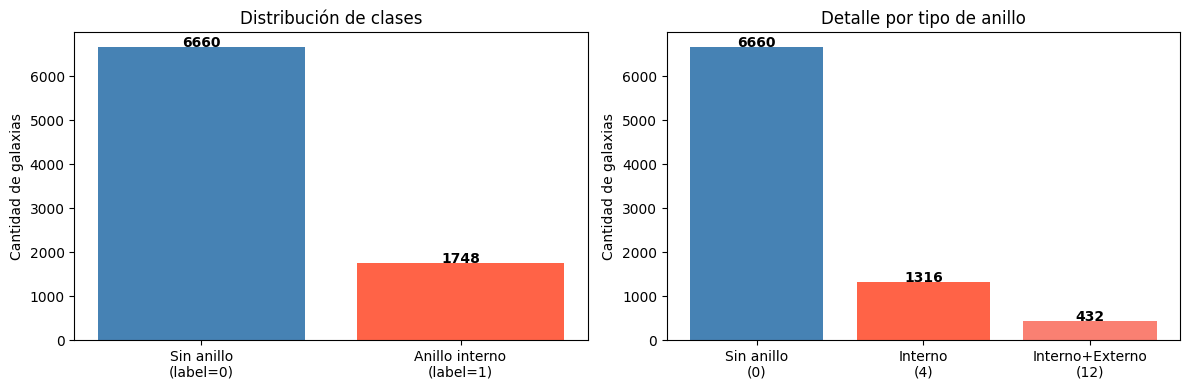

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución por label
counts = df['label'].value_counts().sort_index()
axes[0].bar(['Sin anillo\n(label=0)', 'Anillo interno\n(label=1)'], counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Distribución de clases')
axes[0].set_ylabel('Cantidad de galaxias')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Distribución por tipo de anillo original
ring_counts = df['anillos'].value_counts().sort_index()
labels_map = {0: 'Sin anillo\n(0)', 4: 'Interno\n(4)', 12: 'Interno+Externo\n(12)'}
axes[1].bar([labels_map[k] for k in ring_counts.index], ring_counts.values, color=['steelblue', 'tomato', 'salmon'])
axes[1].set_title('Detalle por tipo de anillo')
axes[1].set_ylabel('Cantidad de galaxias')
for i, v in enumerate(ring_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('catalogs/clasification/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Dataset de clasificación

In [ ]:
output_path = 'catalogs/clasification/classification_dataset.csv'
df.to_csv(output_path, index=False)

print(f'Dataset guardado en: {output_path}')
print(f'Columnas: {list(df.columns)}')
print(f'\nResumen final:')
print(df.groupby(['source', 'label'])['name'].count().rename('galaxias'))

Dataset guardado en: catalogs/classification_dataset.csv
Columnas: ['name', 'objra', 'objdec', 'nsa_z', 'anillos', 'source', 'label']

Resumen final:
source  label
manga   1         519
sdss    0        6660
        1        1229
Name: galaxias, dtype: int64
